In [ ]:
!pip install -U insightface onnxruntime-gpu opencv-python

!mkdir -p /root/.insightface/models

!wget https://github.com/deepinsight/insightface/releases/download/v0.7/inswapper_128.onnx \
-O /root/.insightface/models/inswapper_128.onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 88.9 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071488 sha256=7bee2fbe83e0faec99642b76dba7139ce6e9909cd5699bb88b1829deef2d8e23
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface
--2026-03-18 05:04:43--  https://github.com/deepinsight/insightface/releases/download/v0.7/inswapper_128.onnx
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 60766.21KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied prov

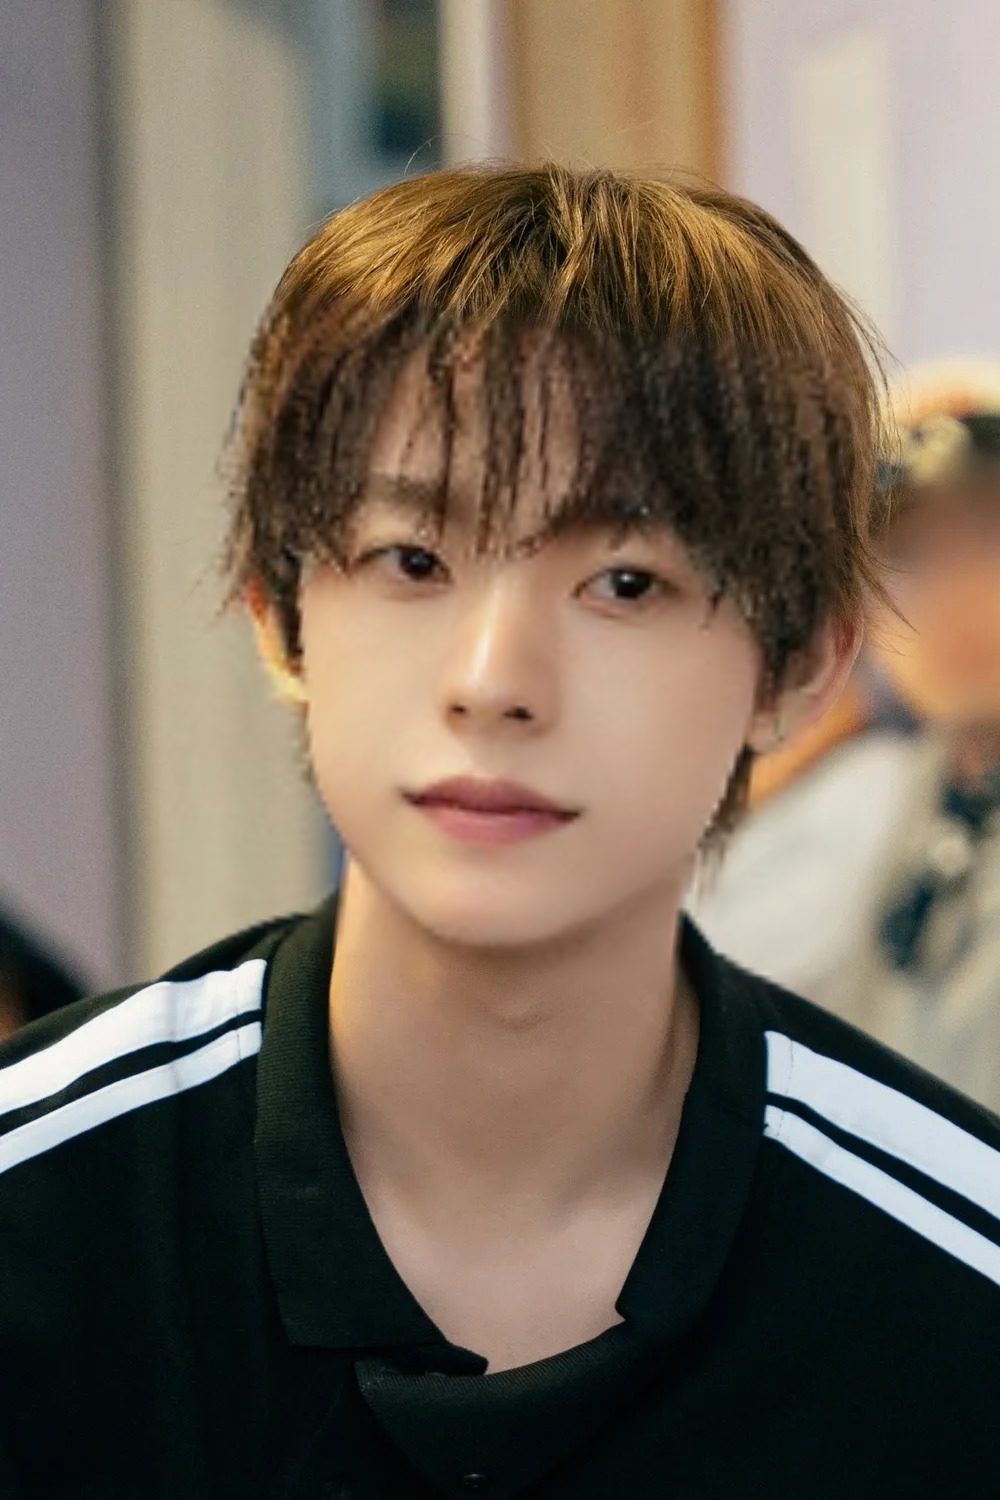

In [ ]:
import cv2
import insightface
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model
from google.colab.patches import cv2_imshow

# 분석 모델
app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(640, 640))   # CPU면 ctx_id=-1

# 스와퍼 모델
swapper = get_model('/root/.insightface/models/inswapper_128.onnx')

# 이미지 로드
target_img = cv2.imread('/content/cortis.jpeg')
source_img = cv2.imread('/content/wish.jpeg')

if target_img is None:
    raise ValueError('target.jpg를 찾을 수 없음')
if source_img is None:
    raise ValueError('source.jpg를 찾을 수 없음')

# 얼굴 추출
target_faces = app.get(target_img)
source_faces = app.get(source_img)

if len(source_faces) == 0:
    raise ValueError('source 이미지에서 얼굴을 찾지 못함')
if len(target_faces) == 0:
    raise ValueError('target 이미지에서 얼굴을 찾지 못함')

# 가장 큰 얼굴을 source로 사용
source_face = max(
    source_faces,
    key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1])
)

# bbox 왼쪽 x 기준 정렬
target_faces = sorted(target_faces, key=lambda x: x.bbox[0])

# swap
result = target_img.copy()
for face in target_faces:
    result = swapper.get(result, face, source_face, paste_back=True)

# 저장/출력
out_path = '/content/result.jpg'
cv2.imwrite(out_path, result)

print(f'target faces: {len(target_faces)}')
print(f'saved: {out_path}')
cv2_imshow(result)

In [ ]:
import cv2
import os
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(320, 320))  # CPU면 ctx_id=-1

swapper = get_model('/root/.insightface/models/inswapper_128.onnx')

source_path = '/content/wish.jpeg'
video_path = '/content/d0.mp4'

source_img = cv2.imread(source_path)
if source_img is None:
    raise ValueError(f'source 이미지 못 읽음: {source_path}')

source_faces = app.get(source_img)
if len(source_faces) == 0:
    raise ValueError('source 이미지에서 얼굴 검출 실패')

source_face = max(
    source_faces,
    key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1])
)

print('모델 준비 완료')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
Applied prov

In [ ]:
import cv2
import os
from tqdm import tqdm

input_video = '/content/d0.mp4'
temp_output = '/content/output_no_audio.mp4'

cap = cv2.VideoCapture(input_video)
if not cap.isOpened():
    raise ValueError(f'영상 열기 실패: {input_video}')

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(temp_output, fourcc, fps, (width, height))

print(f'fps={fps}, size=({width},{height}), frames={frame_count}')

for _ in tqdm(range(frame_count)):
    ret, frame = cap.read()
    if not ret:
        break

    faces = app.get(frame)

    result = frame.copy()
    if len(faces) > 0:
        faces = sorted(faces, key=lambda x: x.bbox[0])  # 왼쪽부터 정렬
        for face in faces:
            result = swapper.get(result, face, source_face, paste_back=True)

    writer.write(result)

cap.release()
writer.release()

print('완료:', temp_output)

fps=25.0, size=(512,512), frames=78


 41%|████      | 32/78 [04:07<05:55,  7.73s/it]


KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download('/content/output_no_audio.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
from tqdm import tqdm

input_video = '/content/d0.mp4'
temp_output = '/content/output_fast_no_audio.mp4'

cap = cv2.VideoCapture(input_video)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(temp_output, fourcc, fps, (width, height))

cached_faces = []
detect_interval = 7
idx = 0

for _ in tqdm(range(frame_count)):
    ret, frame = cap.read()
    if not ret:
        break

    if idx % detect_interval == 0 or len(cached_faces) == 0:
        cached_faces = app.get(frame)

    result = frame.copy()
    if len(cached_faces) > 0:
        cached_faces = sorted(cached_faces, key=lambda x: x.bbox[0])
        for face in cached_faces:
            try:
                result = swapper.get(result, face, source_face, paste_back=True)
            except Exception:
                pass

    writer.write(result)
    idx += 1

cap.release()
writer.release()

print('완료:', temp_output)

100%|██████████| 78/78 [08:12<00:00,  6.31s/it]

완료: /content/output_fast_no_audio.mp4


In [ ]:
from google.colab import files
files.download('/content/output_fast_no_audio.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import cv2

video_path = '/content/d0.mp4'
frames_dir = '/content/frames'
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise ValueError(f'영상 열기 실패: {video_path}')

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print('fps:', fps)
print('size:', width, height)
print('frame_count:', frame_count)

idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(f'{frames_dir}/frame_{idx:06d}.png', frame)
    idx += 1

cap.release()
print('추출 완료:', idx)

fps: 25.0
size: 512 512
frame_count: 78
추출 완료: 78


In [ ]:
import cv2
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(320, 320))   # CPU면 ctx_id=-1

swapper = get_model('/root/.insightface/models/inswapper_128.onnx')

source_img = cv2.imread('/content/wish.jpeg')
if source_img is None:
    raise ValueError('source.jpg를 찾을 수 없음')

source_faces = app.get(source_img)
if len(source_faces) == 0:
    raise ValueError('source 이미지에서 얼굴 검출 실패')

source_face = max(
    source_faces,
    key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1])
)

print('모델 준비 완료')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
Applied prov

In [ ]:
import os
import cv2
from glob import glob
from tqdm import tqdm

frames_dir = '/content/frames'
swapped_dir = '/content/swapped_frames_fast'
os.makedirs(swapped_dir, exist_ok=True)

frame_paths = sorted(glob(f'{frames_dir}/*.png'))
print('총 프레임 수:', len(frame_paths))

detect_interval = 7
cached_faces = []

for idx, frame_path in enumerate(tqdm(frame_paths)):
    frame = cv2.imread(frame_path)
    if frame is None:
        continue

    if idx % detect_interval == 0 or len(cached_faces) == 0:
        cached_faces = app.get(frame)

    result = frame.copy()
    if len(cached_faces) > 0:
        cached_faces = sorted(cached_faces, key=lambda x: x.bbox[0])
        for face in cached_faces:
            try:
                result = swapper.get(result, face, source_face, paste_back=True)
            except Exception:
                pass

    out_path = os.path.join(swapped_dir, os.path.basename(frame_path))
    cv2.imwrite(out_path, result)

print('프레임 처리 완료')

총 프레임 수: 78


100%|██████████| 78/78 [07:56<00:00,  6.10s/it]

프레임 처리 완료


In [ ]:
!ffmpeg -y -framerate 30 -i /content/swapped_frames_fast/frame_%06d.png \
-c:v libx264 -pix_fmt yuv420p /content/output_frame.mp4

In [ ]:
from google.colab import files
files.download('/content/output_frame.mp4')

In [ ]:
!pip install -U insightface onnxruntime-gpu opencv-python numpy tqdm
!mkdir -p /root/.insightface/models
!wget -q https://github.com/deepinsight/insightface/releases/download/v0.7/inswapper_128.onnx \
  -O /root/.insightface/models/inswapper_128.onnx
!apt-get -y install ffmpeg > /dev/null

In [ ]:
import cv2
import os
import math
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import List, Optional
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

# -----------------------------
# 설정
# -----------------------------
SOURCE_PATH = "/content/wish.jpeg"
VIDEO_PATH = "/content/d0.mp4"

OUTPUT_NO_AUDIO = "/content/deep_live_cam_style_no_audio.mp4"
OUTPUT_FINAL = "/content/deep_live_cam_style_final.mp4"

CTX_ID = 0          # GPU면 0, CPU면 -1
# DET_SIZE = (320, 320)

# REDETECT_INTERVAL = 10   # 전체 프레임 얼굴 재검출 주기
# SWAP_INTERVAL = 2        # tracker 기반 crop에서 실제 swap 갱신 주기
# MAX_FACES = 3            # 최대 처리 얼굴 수
# TRACKER_TYPE = "KCF"     # KCF 또는 CSRT
REDETECT_INTERVAL = 15
SWAP_INTERVAL = 3
DET_SIZE = (256, 256)
MAX_FACES = 2
TRACKER_TYPE = "KCF"
CROP_MARGIN = 0.35       # bbox 주변 여유 crop 비율

# -----------------------------
# 모델
# -----------------------------
app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=CTX_ID, det_size=DET_SIZE)

swapper = get_model('/root/.insightface/models/inswapper_128.onnx')

# -----------------------------
# source face 준비
# -----------------------------
source_img = cv2.imread(SOURCE_PATH)
if source_img is None:
    raise ValueError(f"source 이미지 로드 실패: {SOURCE_PATH}")

source_faces = app.get(source_img)
if len(source_faces) == 0:
    raise ValueError("source 이미지에서 얼굴을 찾지 못함")

source_face = max(
    source_faces,
    key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1])
)

print("모델 준비 완료")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 71272.74KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [ ]:
import cv2
import numpy as np
from typing import Tuple

def create_tracker(tracker_type="KCF"):
    tracker_type = tracker_type.upper()
    if tracker_type == "CSRT":
        return cv2.legacy.TrackerCSRT_create() if hasattr(cv2, "legacy") else cv2.TrackerCSRT_create()
    return cv2.legacy.TrackerKCF_create() if hasattr(cv2, "legacy") else cv2.TrackerKCF_create()

def bbox_xyxy_to_xywh(bbox):
    x1, y1, x2, y2 = bbox
    return (float(x1), float(y1), float(x2 - x1), float(y2 - y1))

def bbox_xywh_to_xyxy(bbox):
    x, y, w, h = bbox
    return np.array([x, y, x + w, y + h], dtype=np.float32)

def clip_bbox_xyxy(bbox, w, h):
    x1, y1, x2, y2 = bbox
    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w - 1, x2))
    y2 = max(0, min(h - 1, y2))
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    if union <= 0:
        return 0.0
    return inter / union

def expand_bbox_xyxy(bbox, margin, img_w, img_h):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    mx = bw * margin
    my = bh * margin
    ex1 = max(0, int(x1 - mx))
    ey1 = max(0, int(y1 - my))
    ex2 = min(img_w - 1, int(x2 + mx))
    ey2 = min(img_h - 1, int(y2 + my))
    return ex1, ey1, ex2, ey2

def face_area(face):
    b = face.bbox
    return max(0, b[2] - b[0]) * max(0, b[3] - b[1])

class SimpleFace:
    def __init__(self, bbox, kps):
        self.bbox = bbox.astype(np.float32)
        self.kps = kps.astype(np.float32)

@dataclass
class Track:
    track_id: int
    tracker: any
    bbox_xyxy: np.ndarray
    last_face: Optional[object] = None
    last_seen_frame: int = 0
    missed: int = 0
    active: bool = True

def detect_faces(frame):
    faces = app.get(frame)
    faces = sorted(faces, key=face_area, reverse=True)[:MAX_FACES]
    return faces

def init_tracks_from_detections(frame, detections, next_track_id):
    tracks = []
    for det in detections:
        tracker = create_tracker(TRACKER_TYPE)
        xywh = bbox_xyxy_to_xywh(det.bbox)
        tracker.init(frame, xywh)
        tracks.append(
            Track(
                track_id=next_track_id,
                tracker=tracker,
                bbox_xyxy=np.array(det.bbox, dtype=np.float32),
                last_face=det,
                last_seen_frame=0,
                missed=0,
                active=True
            )
        )
        next_track_id += 1
    return tracks, next_track_id

def update_trackers(frame, tracks):
    updated_tracks = []
    for t in tracks:
        ok, xywh = t.tracker.update(frame)
        if ok:
            t.bbox_xyxy = bbox_xywh_to_xyxy(xywh)
            t.missed = 0
            t.active = True
            updated_tracks.append(t)
        else:
            t.missed += 1
            if t.missed <= 5:
                updated_tracks.append(t)
    return updated_tracks

def match_detections_to_tracks(frame, tracks, detections, frame_idx, iou_thresh=0.25):
    used_dets = set()

    # 기존 track에 detection 매칭
    for t in tracks:
        best_iou = 0.0
        best_j = -1
        for j, det in enumerate(detections):
            if j in used_dets:
                continue
            score = iou_xyxy(t.bbox_xyxy, det.bbox)
            if score > best_iou:
                best_iou = score
                best_j = j

        if best_j >= 0 and best_iou >= iou_thresh:
            det = detections[best_j]
            used_dets.add(best_j)
            t.bbox_xyxy = np.array(det.bbox, dtype=np.float32)
            t.last_face = det
            t.last_seen_frame = frame_idx
            t.missed = 0
            t.active = True

            tracker = create_tracker(TRACKER_TYPE)
            tracker.init(frame, bbox_xyxy_to_xywh(det.bbox))
            t.tracker = tracker
        else:
            t.missed += 1

    # 매칭 안 된 detection은 새 track 생성
    next_id = max([t.track_id for t in tracks], default=-1) + 1
    for j, det in enumerate(detections):
        if j in used_dets:
            continue
        tracker = create_tracker(TRACKER_TYPE)
        tracker.init(frame, bbox_xyxy_to_xywh(det.bbox))
        tracks.append(
            Track(
                track_id=next_id,
                tracker=tracker,
                bbox_xyxy=np.array(det.bbox, dtype=np.float32),
                last_face=det,
                last_seen_frame=frame_idx,
                missed=0,
                active=True
            )
        )
        next_id += 1

    tracks = [t for t in tracks if t.missed <= 8]
    tracks = sorted(tracks, key=lambda x: (x.bbox_xyxy[2] - x.bbox_xyxy[0]) * (x.bbox_xyxy[3] - x.bbox_xyxy[1]), reverse=True)
    tracks = tracks[:MAX_FACES]
    return tracks

def refine_face_on_crop(frame, track: Track):
    h, w = frame.shape[:2]
    bbox = clip_bbox_xyxy(track.bbox_xyxy, w, h)
    ex1, ey1, ex2, ey2 = expand_bbox_xyxy(bbox, CROP_MARGIN, w, h)
    crop = frame[ey1:ey2, ex1:ex2]
    if crop.size == 0:
        return None

    crop_faces = app.get(crop)
    if len(crop_faces) == 0:
        return None

    # crop 안에서 가장 큰 얼굴 선택
    best = max(crop_faces, key=face_area)

    global_bbox = best.bbox.copy()
    global_bbox[[0, 2]] += ex1
    global_bbox[[1, 3]] += ey1

    global_kps = best.kps.copy()
    global_kps[:, 0] += ex1
    global_kps[:, 1] += ey1

    refined = SimpleFace(global_bbox, global_kps)
    return refined

def draw_debug(frame, tracks):
    vis = frame.copy()
    for t in tracks:
        x1, y1, x2, y2 = t.bbox_xyxy.astype(int)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, f"id={t.track_id}", (x1, max(0, y1-8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    return vis

In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise ValueError(f"영상 로드 실패: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

writer = cv2.VideoWriter(
    OUTPUT_NO_AUDIO,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

print("fps:", fps)
print("size:", width, height)
print("frames:", frame_count)

tracks: List[Track] = []
next_track_id = 0

for frame_idx in tqdm(range(frame_count)):
    ret, frame = cap.read()
    if not ret:
        break

    # 1) tracker 업데이트
    if len(tracks) > 0:
        tracks = update_trackers(frame, tracks)

    # 2) 주기적으로 전체 프레임 재검출
    if frame_idx % REDETECT_INTERVAL == 0 or len(tracks) == 0:
        detections = detect_faces(frame)
        if len(tracks) == 0:
            tracks, next_track_id = init_tracks_from_detections(frame, detections, next_track_id)
            for t in tracks:
                t.last_seen_frame = frame_idx
        else:
            tracks = match_detections_to_tracks(frame, tracks, detections, frame_idx)

    result = frame.copy()

    # 3) 각 track에 대해 주기적으로 local crop refine + swap
    for t in tracks[:MAX_FACES]:
        need_refine = (frame_idx % SWAP_INTERVAL == 0) or (t.last_face is None)

        if need_refine:
            refined_face = refine_face_on_crop(frame, t)
            if refined_face is not None:
                t.last_face = refined_face
                t.bbox_xyxy = refined_face.bbox.copy()

        if t.last_face is not None:
            try:
                result = swapper.get(result, t.last_face, source_face, paste_back=True)
            except Exception:
                pass

    writer.write(result)

cap.release()
writer.release()

print("영상 처리 완료:", OUTPUT_NO_AUDIO)

fps: 25.0
size: 512 512
frames: 78


100%|██████████| 78/78 [00:36<00:00,  2.13it/s]

영상 처리 완료: /content/deep_live_cam_style_no_audio.mp4


In [ ]:
from google.colab import files
files.download("/content/deep_live_cam_style_no_audio.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>